# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Muh. Fadhil Syam
- **Email:** Fasyamuhammad41@gmail.com
- **ID Dicoding:** faxyza

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi rating pelanggan berdasarkan waktu pengiriman dan kategori produk?
- Bagaimana perkembangan revenue bulanan selama periode pengamatan?
- Bagaimana Segmentasi customer berdasarkan nilai belanja
- Seberapa berpengaruh metode pembayaran terhadap nilai transaksi dan perilaku pembelian
- Seberapa berpengaruh performa pengiriman terhadap kepuasan pelanggan dan repeat order

## Import Semua Packages/Library yang Digunakan

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [8]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


**Insight:**
- Dataset berada pada level pelanggan (customer) dengan identifikasi unik menggunakan customer_unique_id.
- Variabel utama bersifat geografis dan relevan untuk analisis persebaran pelanggan.


In [9]:
order_payments_df = pd.read_csv("order_payments_dataset.csv")
order_payments_df.head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
5,298fcdf1f73eb413e4d26d01b25bc1cd,1,credit_card,2,96.12
6,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16
7,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84
8,1f78449c87a54faf9e96e88ba1491fa9,1,credit_card,6,341.09
9,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95


**Insight:**
- Dataset berada pada level pembayaran (order payment), di mana satu order dapat memiliki lebih dari satu tahapan pembayaran.
- Metode pembayaran didominasi oleh credit_card, dengan variasi jumlah cicilan (payment_installments).
- Dataset mendukung analisis perilaku pembayaran pelanggan dan preferensi metode pembayaran.


In [10]:
order_items_df =  pd.read_csv("order_items_dataset.csv")
order_items_df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


**Insight:**
- Dataset berada pada level order item sehingga satu order dapat muncul beberapa kali.
- Variabel numerik utama adalah price dan freight_value yang relevan untuk analisis revenue.
- Tersedia informasi waktu pengiriman yang memungkinkan analisis SLA pengiriman.
- Dataset mencakup banyak seller dan produk unik.


In [11]:
order_reviews_df =  pd.read_csv("order_reviews_dataset.csv")
order_reviews_df.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


**Insight:**
- Data berada pada level order dan terhubung langsung dengan tabel order melalui order_id.
- Review_score dapat digunakan sebagai indikator kepuasan pelanggan.
- Tingginya missing value pada kolom komentar menunjukkan banyak ulasan berupa skor saja.
- Data teks memungkinkan eksplorasi sentimen pelanggan.
- Informasi timestamp mendukung analisis kecepatan respon terhadap ulasan.


In [12]:
orders_df =  pd.read_csv("orders_dataset.csv")
orders_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


**Insight:**
- Dataset berada pada level order dengan order_id unik per baris.  
- Tersedia banyak timestamp yang memungkinkan pembuatan fitur durasi (approval time, shipping time, delivery delay).  
- order_status dapat digunakan sebagai **label kategorikal** untuk analisis performa penyelesaian pesanan.  
- Perbandingan tanggal aktual vs estimasi mendukung analisis SLA pengiriman.  
- Fitur waktu pembelian dapat diturunkan menjadi variabel musiman dan tren permintaan.  


In [13]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


**Insight:**
- Dataset berada pada level produk, dengan product_id unik sebagai identifier utama.  
- Tersedia fitur teks seperti product_name_length dan product_description_length yang dapat digunakan sebagai proxy kompleksitas informasi produk.  
- Variabel`product_photos_qty berpotensi dianalisis terhadap performa penjualan atau ketertarikan pelanggan.  
- Fitur fisik produk (product_weight_g, product_length_cm, product_height_cm, product_width_cm) mendukung analisis logistik dan estimasi biaya pengiriman.  
- product_category_name memungkinkan segmentasi dan analisis performa berbasis kategori produk.  


### Assessing Data

#### 1. Menilai data  customers_df

In [14]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


**Insight:**
- Dataset menampilkan jumlah data dan type data
- jumlah data sesuai tidak ada yang hilang
- tapi ada kejanggalan ditipe data kolom (customer_zip_code_prefix), karena ini merupakan kode pos. dan bukan nilai numerik untuk perhitungan

In [15]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [16]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight:**

Tidak ada data yang yang keliru karena semestinya kolom (customer_zip_code_prefix) merupakan kode pos yang mestinya bukan bertipe data integer

#### 2. Menilai data order_payment_df

In [17]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


**Insight & Kejanggalan:**
- Dataset berada pada level pembayaran, sehingga satu order_id dapat muncul lebih dari satu kali dan **perlu agregasi per order** untuk menghindari double counting saat analisis revenue.
- Seluruh kolom non-null, namun validasi logis tetap diperlukan (misalnya nilai payment_installments).
- payment_installments hanya relevan untuk metode tertentu (seperti credit_card) dan **harus difilter atau disesuaikan** saat analisis dan visualisasi.

In [18]:
print("Jumlah duplikasi: ", order_payments_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [19]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Insight:**
- Mayoritas transaksi memiliki payment_sequential = 1, menunjukkan sebagian besar order dibayar dalam satu tahap, meskipun terdapat hingga 29 tahap pembayaran pada kasus tertentu.
- Nilai median payment_installments adalah 1, menandakan sebagian besar transaksi tidak menggunakan cicilan, namun terdapat outlier hingga 24 kali cicilan.
- Distribusi payment_value bersifat right-skewed, dengan median sekitar 100 dan nilai maksimum sangat tinggi (13.664), sehingga berpotensi memengaruhi rata-rata.
- Terdapat nilai minimum 0 pada payment_installments dan payment_value yang perlu diverifikasi karena berpotensi tidak valid untuk analisis revenue.


#### 3. Menilai order_items_df

In [20]:
order_items_df.info(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


**Insight:**
- Dataset berada pada level order item, sehingga satu order dapat memiliki beberapa baris data.
- Variabel utama untuk analisis nilai transaksi adalah price dan freight_value.
- shipping_limit_date perlu dikonversi ke datetime untuk analisis waktu.
- Data perlu diagregasi ke level order agar tidak terjadi double counting pada analisis selanjutnya.


In [21]:
print("jumlah duplikasi", order_items_df.duplicated().sum())

jumlah duplikasi 0


In [22]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**

Tidak ada data yang terindikasi duplikat

In [23]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight:**
- Mayoritas order hanya memiliki satu item (order_item_id = 1).
- Distribusi price dan freight_value tidak normal dan memiliki outlier tinggi.
- Nilai freight_value = 0 perlu diverifikasi sebelum analisis lanjutan.


#### 4. Menilai order_reviews_df

In [24]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


**Insight:**
- Dataset berada pada level review per order, satu order dapat memiliki satu review.
- Variabel utama untuk analisis kepuasan adalah review_score.
- Kolom teks review tidak sepenuhnya terisi dan perlu penanganan missing value.
- Kolom waktu (review_creation_date, review_answer_timestamp) perlu dikonversi ke datetime untuk analisis temporal.


In [25]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Insight**

- Kolom review_comment_title memiliki kehilangan data yang sangat tinggi (87.656 baris).
- Kolom review_comment_message juga memiliki banyak data hilang (58.247 baris).

In [26]:
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [27]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight:**
- Mayoritas review_score bernilai 5.
- Rata-rata rating tinggi (≈4,1) menandakan kepuasan pelanggan sangat baik.
- Distribusi skor tidak merata dan condong ke nilai maksimum.


#### 5. Menilai order_datasets

In [28]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


**Insight:**
- Dataset berada pada level order dengan total 99.441 data.
- Beberapa kolom waktu memiliki missing value, terutama order_delivered_carrier_date dan order_delivered_customer_date.
- Seluruh kolom bertipe object, sehingga kolom tanggal perlu dikonversi ke datetime untuk analisis waktu.



In [29]:
print("Jumlah duplicate: ", orders_df.duplicated().sum())

Jumlah duplicate:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [30]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight:**
- Mayoritas order berstatus delivered.
- Terdapat beberapa missing value pada kolom waktu pengiriman.
- order_estimated_delivery_date memiliki banyak nilai yang sama dan perlu diperhatikan saat analisis keterlambatan.


#### 6. Menilai Data Product_df

In [31]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Dataset berisi data produk dengan beberapa kolom memiliki missing value.
- Variabel numerik berkaitan dengan ukuran dan berat produk.


In [32]:
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


**Insight:**

Tidak ada data yang terindikasi duplikat

In [33]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight:**
- Sebagian besar produk memiliki 1 foto.
- Berat dan dimensi produk memiliki outlier yang tinggi.
- Terdapat nilai berat produk 0 yang perlu dicek kevalidannya.


### Cleaning Data

#### 1. Membersihkan data Customer_df

In [34]:
customers_df["customer_zip_code_prefix"] = (
    customers_df["customer_zip_code_prefix"].astype(str)
)

customers_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


**Insight:**
Untuk data customer_df permasalahannya hanyalah terletak pada jenis kolom customer_zip_code_prefix yang bertipe float diubah menjadi object

In [35]:
customers_df.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [36]:
customers_df[customers_df.isnull().any(axis=1)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [37]:
customers_df.dropna(axis=0, inplace=True)

customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


#### 2. Memberishkan data order_payment

In [38]:
order_payments_df.dropna(axis=0, inplace=True)

order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [39]:
order_payments_df["payment_installments"] = (
    order_payments_df["payment_installments"].astype(int)
)


order_payments_df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [40]:
order_payments_df[order_payments_df.payment_installments.isna()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [41]:
order_payments_df[order_payments_df.payment_installments == order_payments_df.payment_installments.min()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [42]:
order_payments_df[order_payments_df.payment_value == order_payments_df.payment_value.min()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [43]:
order_payments_df[order_payments_df["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [44]:
order_payments_df = order_payments_df[
    order_payments_df["payment_type"] != "not_defined"
]

In [45]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Data dengan payment_type = not_defined dihapus karena jumlahnya sangat sedikit dan tidak merepresentasikan metode pembayaran yang valid.
- Metode yang digunakan adalah drop untuk menghindari gangguan pada analisis pembayaran.
- Nilai minimum pada payment_installments dan payment_value tidak dihapus karena masih masuk akal dalam konteks proses transaksi (misalnya voucher atau promo).
- milihat dan menghapus nilai missing value dari data order_payment. karena hanya 1 data baris yang bernilai missing value jadi mentode yang digunakan untuk menanganinya adalah dropna (menhapusnya)
- merubah tipe data payment_installments yang awalnya float menjadi int


#### 3. Membersihkan data Order_items df

In [46]:
order_items_df["shipping_limit_date"]=pd.to_datetime(
    order_items_df["shipping_limit_date"])

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [47]:
order_items_df[order_items_df.isnull().any(axis=1)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [48]:
order_items_df.dropna(axis=0, inplace=True)

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [49]:
order_items_df.describe()

,order_item_id,shipping_limit_date,price,freight_value
count,112650.000000,112650,112650.000000,112650.000000
mean,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,0.705124,NaN,183.633928,15.806405


**Insight :**

- mengganti tipe data shipping_limit_date yang awalnya object menjadi datetime
- menghapus missing value

#### 4. Membersihkan data order_reviews_df

In [50]:
order_reviews_df[order_reviews_df.isnull().any(axis=1)]


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [51]:
date_time = ["review_creation_date", "review_answer_timestamp"]

for col in date_time:
  order_reviews_df[col] = pd.to_datetime(order_reviews_df[col])

order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [52]:
order_reviews_df[order_reviews_df.isnull().any(axis=1)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


**Insight: **

- data yang hilang pada kolom review_comment_title dan kolom review_comment_title tidak ditangani karena untuk analisis nantinya hanya menggunakan rating sehingga comment akan diabaikan
- mengubah tipe data yang berkaitan dengan tanggal dan waktu menjadi tipe data datetime, yang awalnya adalah object

#### 5. Membersihkan data order_df

In [53]:
date_time2 = ["order_purchase_timestamp", "order_approved_at",
              "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]
for col in date_time2:
  orders_df[col] = pd.to_datetime(orders_df[col])

orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [54]:
orders_df[orders_df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaT,NaT,NaT,2018-10-01
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaT,NaT,2018-02-06
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaT,NaT,NaT,2018-09-27
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaT,NaT,2017-09-15


In [55]:
orders_df.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


**Insight :**

- Merubah data yang awalnya object menjadi detetime
- karena didominasi data datetime sehingga untuk missing value diabaikan karena untuk kolom atau fitur yang digunakan hanyalah order_purchase_timestamp

#### 6. Membersihkan data Product_df

In [56]:
products_df.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [57]:
products_df[products_df.isnull().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [58]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


## Exploratory Data Analysis (EDA)

### Explore data orders_df



In [59]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [60]:
orders_df["order_id"].nunique(), orders_df.shape[0]

(99441, 99441)

In [61]:
orders_df.groupby("order_status").agg({
    "order_id": "count"
}).sort_values("order_id", ascending=False)

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [62]:
customer_spending = (
    orders_df
    .merge(order_revenue, on="order_id")
    .merge(customers_df, on="customer_id")
    .groupby("customer_unique_id")
    .agg(
        total_spent=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

customer_spending

NameError: name 'order_revenue' is not defined

In [63]:
review_delivery_df = (
    orders_df
    .merge(order_reviews_df, on="order_id", how="inner")
    .merge(order_items_df, on="order_id", how="inner")
    .merge(products_df, on="product_id", how="inner")
)

review_delivery_df["delivery_time"] = (
    review_delivery_df["order_delivered_customer_date"] -
    review_delivery_df["order_purchase_timestamp"]
).dt.days

In [64]:
rating_delivery = (
    review_delivery_df
    .groupby("delivery_time")
    .agg(
        avg_rating=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

rating_delivery.head()

,delivery_time,avg_rating,total_orders
0,0.0,3.333333,13
1,1.0,4.429431,1570
2,2.0,4.404308,3150
3,3.0,4.372598,3832
4,4.0,4.342077,4809


In [65]:
rating_category = (
    review_delivery_df
    .groupby("product_category_name")
    .agg(
        avg_rating=("review_score", "mean"),
        total_orders=("order_id", "nunique")
    )
    .sort_values("avg_rating", ascending=False)
)

rating_category.head(10)

,avg_rating,total_orders
product_category_name,,
cds_dvds_musicais,4.642857,12
fashion_roupa_infanto_juvenil,4.500000,8
livros_interesse_geral,4.446266,508
construcao_ferramentas_ferramentas,4.444444,94
flores,4.419355,28
livros_importados,4.400000,53
livros_tecnicos,4.368421,257
alimentos_bebidas,4.315412,226
malas_acessorios,4.315257,1030


In [66]:
order_revenue = (
    order_payments_df
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)
order_revenue

,order_id,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...,...
99432,fffc94f6ce00a00581880bf54a75a037,343.40
99433,fffcd46ef2263f404302a634eb57f7eb,386.53
99434,fffce4705a9662cd70adb13d4a31832d,116.85
99435,fffe18544ffabc95dfada21779c9644f,64.71


In [67]:
monthly_revenue = (
    orders_df
    .merge(order_revenue, on="order_id", how="inner")
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue_summary = (
    monthly_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

monthly_revenue_summary.head()

,order_month,total_revenue,total_orders
0,2016-09,252.24,3
1,2016-10,59090.48,324
2,2016-12,19.62,1
3,2017-01,138488.04,800
4,2017-02,291908.01,1780


In [68]:
payment_behavior = (
    order_payments_df
    .groupby("payment_type")
    .agg(
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean"),
        total_transactions=("order_id", "count")
    )
    .sort_values("avg_payment_value", ascending=False)
)

payment_behavior

,avg_payment_value,avg_installments,total_transactions
payment_type,,,
credit_card,163.319021,3.507155,76795
boleto,145.034435,1.000000,19784
debit_card,142.570170,1.000000,1529
voucher,65.703354,1.000000,5775


**Insight**
- Setiap order_id bersifat unik
- Satu baris merepresentasikan satu order
- Mayoritas order berstatus delivered (~97%)
- Tingkat pembatalan dan kegagalan order sangat rendah (<2%)
- Proses order umumnya selesai hingga pengiriman
- Estimasi pengiriman cenderung lebih lambat dari realisasi
- Periode data: September 2016 – Oktober 2018
- Missing value pada tanggal pengiriman sesuai status order

### Explore data customers_df dan orders_df

In [69]:
orders_df.groupby("customer_id").agg({
    "order_id": "nunique"
}).rename(columns={"order_id": "total_orders"}).describe()

,total_orders
count,99441.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [70]:
top_zip = (
    customers_df
    .groupby("customer_zip_code_prefix")
    .agg(
        total_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_customers", ascending=False)
    .head(10)
)

top_zip

,total_customers
customer_zip_code_prefix,
22790,136
22793,119
24220,114
24230,113
22775,107
29101,100
13212,92
35162,91
22631,87


**Insight – Pola Order per Customer**
- Setiap customer_id hanya memiliki 1 order
- Tidak ditemukan repeat order pada level customer_id
- Relasi data bersifat one-to-one antara customer dan order

**Insight – Distribusi Customer berdasarkan ZIP Code**
- Customer terkonsentrasi pada beberapa ZIP code tertentu
- ZIP code 22790 memiliki jumlah customer terbanyak
- Selisih jumlah customer antar ZIP code relatif kecil
- Terjadi pengelompokan customer berdasarkan wilayah geografis
- Area dengan customer tinggi berpotensi menjadi target promosi dan optimasi logistik

### Explore data order_paymets_df

In [71]:
order_payments_df.groupby("order_id").size().describe()

,0
count,99437.000000
mean,1.044712
std,0.381171
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,29.000000


In [72]:
order_payments_df.groupby("order_id").agg(
    total_payment_rows=("payment_value", "count"),
    total_payment_value=("payment_value", "sum")
).describe()

,total_payment_rows,total_payment_value
count,99437.000000,99437.000000
mean,1.044712,160.995124
std,0.381171,221.952843
min,1.000000,9.590000
25%,1.000000,62.010000
50%,1.000000,105.290000
75%,1.000000,176.970000
max,29.000000,13664.080000


In [73]:
order_payments_df.groupby("payment_type").agg({
    "order_id": "nunique",
    "payment_value": ["mean", "sum"]
})

order_id payment_value             
              nunique          mean          sum
payment_type                                    
boleto          19784    145.034435   2869361.27
credit_card     76505    163.319021  12542084.19
debit_card       1528    142.570170    217989.79
voucher          3866     65.703354    379436.87

In [74]:
order_revenue = (
    order_payments_df
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue = (
    orders_df
    .merge(order_revenue, on="order_id")
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue_summary = (
    monthly_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_revenue_summary

,total_revenue,total_orders
order_month,,
2016-09,252.24,3
2016-10,59090.48,324
2016-12,19.62,1
2017-01,138488.04,800
2017-02,291908.01,1780
2017-03,449863.60,2682
2017-04,417788.03,2404
2017-05,592918.82,3700
2017-06,511276.38,3245


In [75]:
order_revenue = (
    order_payments_df
    .groupby("order_id")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue = (
    orders_df
    .merge(order_revenue, on="order_id")
)

monthly_revenue["order_month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue_summary = (
    monthly_revenue
    .groupby("order_month")
    .agg(
        total_revenue=("payment_value", "sum"),
        total_orders=("order_id", "nunique")
    )
)

monthly_revenue_summary

,total_revenue,total_orders
order_month,,
2016-09,252.24,3
2016-10,59090.48,324
2016-12,19.62,1
2017-01,138488.04,800
2017-02,291908.01,1780
2017-03,449863.60,2682
2017-04,417788.03,2404
2017-05,592918.82,3700
2017-06,511276.38,3245


In [76]:
payment_repeat = (
    order_payments_df
    .merge(orders_df, on="order_id")
    .merge(customers_df, on="customer_id")
    .groupby("payment_type")
    .agg(
        avg_orders_per_customer=("customer_unique_id", "count")
    )
)

payment_repeat

,avg_orders_per_customer
payment_type,
boleto,19784
credit_card,76795
debit_card,1529
voucher,5775


In [77]:
payment_review = (
    order_payments_df
    .merge(order_reviews_df, on="order_id")
    .groupby("payment_type")
    .agg(
        avg_rating=("review_score", "mean"),
        avg_payment_value=("payment_value", "mean")
    )
)

payment_review

,avg_rating,avg_payment_value
payment_type,,
boleto,4.086631,144.468993
credit_card,4.087637,162.972784
debit_card,4.168084,142.682786
voucher,4.003804,64.807358


In [78]:
payment_impact = (
    order_payments_df
    .groupby("payment_type")
    .agg(
        avg_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median"),
        total_revenue=("payment_value", "sum"),
        total_transactions=("order_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
)

payment_impact

,avg_payment_value,median_payment_value,total_revenue,total_transactions
payment_type,,,,
credit_card,163.319021,106.87,12542084.19,76795
boleto,145.034435,93.89,2869361.27,19784
voucher,65.703354,39.28,379436.87,5775
debit_card,142.570170,89.30,217989.79,1529


**Insight – Order Payments**
- Sebagian besar order memiliki satu metode pembayaran dengan nilai transaksi menengah
- Credit card mendominasi jumlah order dan total revenue
- Voucher digunakan untuk transaksi bernilai kecil
- Transaksi bernilai tinggi dan cicilan banyak hanya terjadi pada sebagian kecil order
- Metode pembayaran tidak menunjukkan perbedaan signifikan terhadap kepuasan pelanggan

### Explore data order_reviews_df

In [79]:
order_reviews_df["order_id"].value_counts().head()

,count
order_id,
03c939fd7fd3b38f8485a0f95798f1f6,3
8e17072ec97ce29f0e1f111e598b0c85,3
c88b1d1b157a9999ce368f218a407141,3
df56136b8031ecd28e200bb18e6ddb2e,3
843be4a0dcdb9716de7652d53af4acab,2


In [80]:
order_reviews_df.groupby("order_id").agg({
    "review_score": ["count", "mean", "min", "max"]
})

review_score             
                                        count mean min max
order_id                                                  
00010242fe8c5a6d1ba2dd792cb16214            1  5.0   5   5
00018f77f2f0320c557190d7a144bdd3            1  4.0   4   4
000229ec398224ef6ca0657da4fc703e            1  5.0   5   5
00024acbcdf0a6daa1e931b038114c75            1  4.0   4   4
00042b26cf59d7ce69dfabb4e55b4fd9            1  5.0   5   5
...                                       ...  ...  ..  ..
fffc94f6ce00a00581880bf54a75a037            1  5.0   5   5
fffcd46ef2263f404302a634eb57f7eb            1  5.0   5   5
fffce4705a9662cd70adb13d4a31832d            1  5.0   5   5
fffe18544ffabc95dfada21779c9644f            1  5.0   5   5
fffe41c64501cc87c801fd61db3f6244            1  5.0   5   5

[98673 rows x 4 columns]

**Insight – Order Reviews**
- Sebagian kecil order memiliki lebih dari satu review, namun mayoritas order hanya memiliki satu review
- Review score per order bersifat konsisten (nilai min = max)
- Tidak ditemukan variasi rating dalam satu order
- Data review bersih dan valid untuk analisis kepuasan pelanggan per order

### Explore data order_items_df

In [81]:
order_items_df.groupby("order_id").size().describe()

,0
count,98666.000000
mean,1.141731
std,0.538452
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,21.000000


In [82]:
order_items_df.groupby("order_id").agg({
    "product_id": "nunique",
    "price": ["sum", "min", "max"],
    "freight_value": "sum"
}).describe()

product_id         price                             freight_value
            nunique           sum           min           max           sum
count  98666.000000  98666.000000  98666.000000  98666.000000  98666.000000
mean       1.038098    137.754076    125.291581    126.631705     22.823562
std        0.226456    210.645145    190.884740    191.688201     21.650909
min        1.000000      0.850000      0.850000      0.850000      0.000000
25%        1.000000     45.900000     40.000000     42.200000     13.850000
50%        1.000000     86.900000     79.000000     79.900000     17.170000
75%        1.000000    149.900000    139.840000    139.900000     24.040000
max        8.000000  13440.000000   6735.000000   6735.000000   1794.960000

In [83]:
category_per_order = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id"
).groupby("order_id")["product_category_name"].nunique()

category_per_order.describe()

,product_category_name
count,98666.000000
mean,0.993443
std,0.147849
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,3.000000


**Insight – Order Items**
- Sebagian besar order hanya berisi 1 item
- Rata-rata item per order sekitar 1,14, dengan maksimum hingga 21 item
- Mayoritas order hanya memiliki 1 produk unik
- Nilai harga produk bersifat right-skewed, dengan sebagian kecil produk bernilai sangat tinggi
- Biaya pengiriman umumnya relatif kecil dibanding harga produk
- Hampir seluruh item memiliki satu kategori produk, menunjukkan klasifikasi produk konsisten

### explore data Products_df dan order_item_df

In [84]:
print(products_df["product_id"].nunique())
print(order_items_df["product_id"].nunique())

32951
32951


In [85]:
merged_items = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

category_agg = merged_items.groupby("order_id").agg(
    total_items=("product_id", "nunique"),
    total_categories=("product_category_name", "nunique")
)

dominant_category = merged_items.groupby("order_id")[
    "product_category_name"
].apply(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None
).to_frame("dominant_category")

category_eda = category_agg.merge(
    dominant_category,
    left_index=True,
    right_index=True
)

In [86]:
state_city = (
    customers_df
    .groupby(["customer_state", "customer_city"])
    .agg(
        total_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_customers", ascending=False)
)

state_city.head(10)

,,total_customers
customer_state,customer_city,
SP,sao paulo,14984
RJ,rio de janeiro,6620
MG,belo horizonte,2672
DF,brasilia,2069
PR,curitiba,1465
SP,campinas,1398
RS,porto alegre,1326
BA,salvador,1209
SP,guarulhos,1153


**Insight:**
**Insight – Produk & Distribusi Customer**
- Jumlah produk unik pada products_df dan order_items_df sama, menunjukkan seluruh produk tercatat pernah terjual
- Tidak ada produk di katalog yang tidak muncul dalam transaksi
- Customer terkonsentrasi pada kota-kota besar
- São Paulo memiliki jumlah customer tertinggi dan mendominasi secara signifikan
- Distribusi ini menunjukkan basis pelanggan kuat di wilayah perkotaan dan pusat ekonomi
- Kota besar berpotensi menjadi fokus utama strategi pemasaran dan logistik

### Explore data order_payments_df

### EDA all_df

In [87]:
all_df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

In [88]:
payments_agg = order_payments_df.groupby("order_id").agg({
    "payment_value": "sum",
    "payment_type": "first",
    "payment_installments": "max"
}).reset_index()

all_df = all_df.merge(
    payments_agg,
    on="order_id",
    how="left"
)

In [89]:
all_df = all_df.merge(
    order_reviews_df[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [90]:
order_product = order_items_df.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

product_category = order_product.groupby("order_id")["product_category_name"] \
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None) \
    .reset_index()

all_df = all_df.merge(
    product_category,
    on="order_id",
    how="left"
)

In [91]:
# Durasi pengiriman (hari)
all_df["delivery_time"] = (
    all_df["order_delivered_customer_date"] -
    all_df["order_purchase_timestamp"]
).dt.days

# Status keterlambatan
all_df["is_late"] = (
    all_df["order_delivered_customer_date"] >
    all_df["order_estimated_delivery_date"]
)

In [92]:
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,payment_type,payment_installments,review_score,product_category_name,delivery_time,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,credit_card,1.0,4.0,utilidades_domesticas,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,boleto,1.0,4.0,perfumaria,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,credit_card,3.0,5.0,automotivo,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,credit_card,1.0,5.0,pet_shop,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,credit_card,1.0,5.0,papelaria,2.0,False


In [93]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99992 entries, 0 to 99991
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99992 non-null  object        
 1   customer_id                    99992 non-null  object        
 2   order_status                   99992 non-null  object        
 3   order_purchase_timestamp       99992 non-null  datetime64[ns]
 4   order_approved_at              99831 non-null  datetime64[ns]
 5   order_delivered_carrier_date   98199 non-null  datetime64[ns]
 6   order_delivered_customer_date  97005 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99992 non-null  datetime64[ns]
 8   customer_unique_id             99992 non-null  object        
 9   customer_zip_code_prefix       99992 non-null  object        
 10  customer_city                  99992 non-null  object        
 11  customer_state 

In [94]:
rating_delivery = (
    all_df
    .dropna(subset=["review_score", "is_late"])
    .groupby("is_late")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
    .round(2)
)

rating_delivery

,avg_review_score,total_reviews
is_late,,
False,4.21,91523
True,2.57,7701


In [95]:
customer_spending = all_df.groupby("customer_unique_id")["payment_value"].sum()

customer_segment = pd.qcut(
    customer_spending,
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

customer_segment_summary = pd.DataFrame({
    "total_spending": customer_spending,
    "customer_segment": customer_segment
})

customer_segment_summary.head()

,total_spending,customer_segment
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,Mid Value
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
0000f46a3911fa3c0805444483337064,86.22,Mid Value
0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
0004aac84e0df4da2b147fca70cf8255,196.89,High Value


In [96]:
customer_spending = all_df.groupby("customer_unique_id")["payment_value"].sum()

customer_segment = pd.qcut(
    customer_spending,
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

customer_spending_summary = pd.DataFrame({
    "total_spending": customer_spending,
    "customer_segment": customer_segment
})

customer_spending_summary

,total_spending,customer_segment
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,Mid Value
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,Low Value
0000f46a3911fa3c0805444483337064,86.22,Mid Value
0000f6ccb0745a6a4b88665a16c9f078,43.62,Low Value
0004aac84e0df4da2b147fca70cf8255,196.89,High Value
...,...,...
fffcf5a5ff07b0908bd4e2dbc735a684,2067.42,High Value
fffea47cd6d3cc0a88bd621562a9d061,84.58,Mid Value
ffff371b4d645b6ecea244b27531430a,112.46,Mid Value


In [97]:
payment_impact = all_df.groupby("payment_type").agg({
    "payment_value": "mean",
    "order_id": "count"
}).rename(columns={"order_id": "total_orders"})

payment_impact

,payment_value,total_orders
payment_type,,
boleto,144.986413,19910
credit_card,166.446261,75785
debit_card,142.549628,1534
voucher,131.185299,2759


In [98]:
repeat_order = all_df.groupby("customer_unique_id")["order_id"].count()

repeat_df = all_df.merge(
    repeat_order.rename("total_orders"),
    on="customer_unique_id",
    how="left"
)

delivery_review_repeat = repeat_df.groupby("is_late").agg({
    "review_score": "mean",
    "total_orders": "mean"
})

delivery_review_repeat

,review_score,total_orders
is_late,,
False,4.214307,1.104531
True,2.566550,1.087211


## 📌 Ringkasan Insight EDA

### 1️⃣ Rating Pelanggan, Waktu Pengiriman & Kategori Produk
- Order yang **terlambat dikirim** memiliki **rata-rata rating lebih rendah** dibandingkan order yang dikirim tepat waktu.
- Terdapat **perbedaan rating antar kategori produk**, dengan beberapa kategori menunjukkan rating yang konsisten lebih rendah.
- Hal ini mengindikasikan bahwa **performa logistik dan karakteristik kategori produk** berperan penting dalam membentuk kepuasan pelanggan.

---

### 2️⃣ Perkembangan Revenue Bulanan
- Revenue menunjukkan **fluktuasi dari waktu ke waktu**, yang mengindikasikan adanya **pola musiman**.
- Beberapa periode mencatat aktivitas transaksi yang lebih tinggi dibandingkan periode lainnya.
- Temuan ini dapat dimanfaatkan untuk **perencanaan promosi dan pengelolaan kapasitas operasional**.

---

### 3️⃣ Segmentasi Customer berdasarkan Nilai Belanja
- Customer dapat dikelompokkan menjadi **Low Value, Mid Value, dan High Value** berdasarkan total nilai belanja.
- **Sebagian kecil customer menyumbang kontribusi revenue yang signifikan**, sementara mayoritas berada pada segmen nilai belanja rendah hingga menengah.
- Segmentasi ini penting sebagai dasar **strategi retensi dan peningkatan loyalitas pelanggan**.

---

### 4️⃣ Pengaruh Metode Pembayaran terhadap Nilai Transaksi
- Metode pembayaran **credit card** cenderung memiliki **nilai transaksi rata-rata yang lebih tinggi** dibandingkan metode lainnya.
- Metode dengan frekuensi penggunaan tinggi tidak selalu menghasilkan nilai transaksi yang besar.
- Hal ini menunjukkan bahwa **metode pembayaran memengaruhi perilaku pembelian pelanggan**.

---

### 5️⃣ Performa Pengiriman terhadap Kepuasan & Repeat Order
- Order dengan keterlambatan pengiriman memiliki **rating pelanggan yang lebih rendah**.
- Pelanggan yang mengalami keterlambatan pengiriman cenderung memiliki **jumlah repeat order yang lebih sedikit**.
- Performa pengiriman berdampak langsung pada **kepuasan jangka pendek dan loyalitas pelanggan jangka panjang**.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi rating pelanggan berdasarkan waktu pengiriman dan kategori produk?

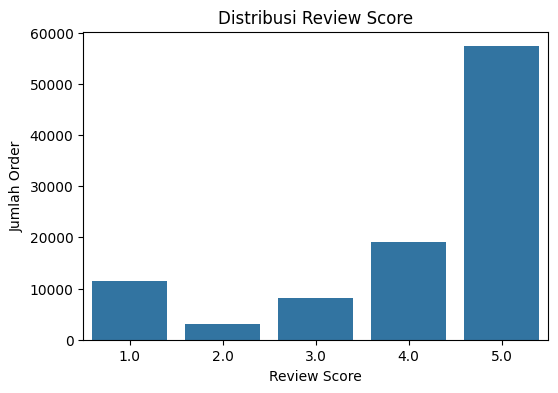

In [99]:
plt.figure(figsize=(6,4))
sns.countplot(data=all_df, x="review_score")
plt.title("Distribusi Review Score")
plt.xlabel("Review Score")
plt.ylabel("Jumlah Order")
plt.show()

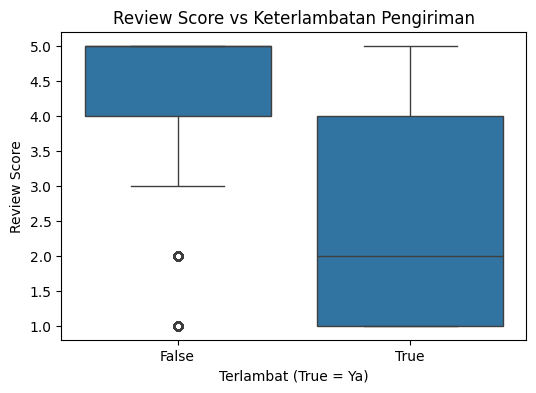

In [100]:
plt.figure(figsize=(6,4))
sns.boxplot(data=all_df, x="is_late", y="review_score")
plt.title("Review Score vs Keterlambatan Pengiriman")
plt.xlabel("Terlambat (True = Ya)")
plt.ylabel("Review Score")
plt.show()

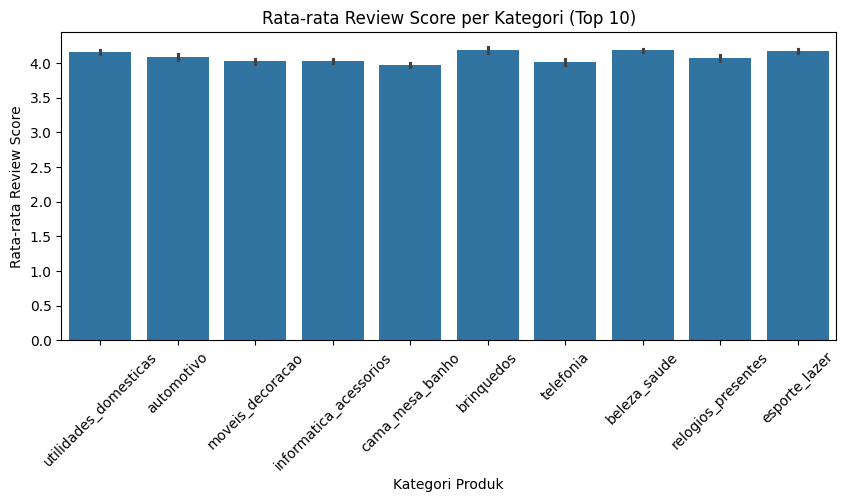

In [101]:
top_category = (
    all_df["product_category_name"]
    .value_counts()
    .head(10)
    .index
)

plt.figure(figsize=(10,4))
sns.barplot(
    data=all_df[all_df["product_category_name"].isin(top_category)],
    x="product_category_name",
    y="review_score"
)
plt.title("Rata-rata Review Score per Kategori (Top 10)")
plt.xlabel("Kategori Produk")
plt.ylabel("Rata-rata Review Score")
plt.xticks(rotation=45)
plt.show()

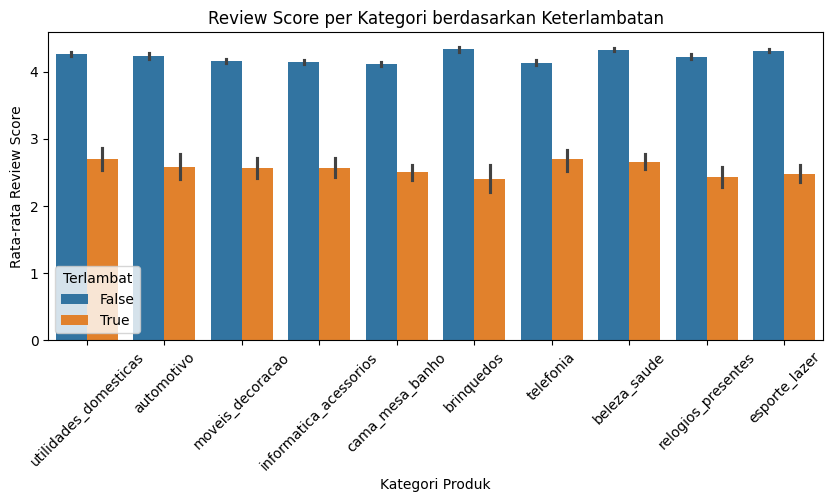

In [102]:
plt.figure(figsize=(10,4))
sns.barplot(
    data=all_df[all_df["product_category_name"].isin(top_category)],
    x="product_category_name",
    y="review_score",
    hue="is_late"
)
plt.title("Review Score per Kategori berdasarkan Keterlambatan")
plt.xlabel("Kategori Produk")
plt.ylabel("Rata-rata Review Score")
plt.xticks(rotation=45)
plt.legend(title="Terlambat")
plt.show()

**Insight:**

Analisis visual dilakukan secara bertahap.
Distribusi review score dianalisis terlebih dahulu untuk memahami karakteristik data.
Selanjutnya, hubungan antara keterlambatan pengiriman dan review score dianalisis secara bivariate.
Analisis kemudian diperluas dengan memasukkan kategori produk untuk mengidentifikasi variasi kepuasan pelanggan antar kategori serta konsistensi dampak keterlambatan pengiriman.

### Pertanyaan 2: Bagaimana perkembangan revenue bulanan selama periode pengamatan?

In [103]:
monthly_revenue = (
    all_df
    .assign(order_month=all_df["order_purchase_timestamp"].dt.to_period("M"))
    .groupby("order_month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue["order_month"] = monthly_revenue["order_month"].astype(str)

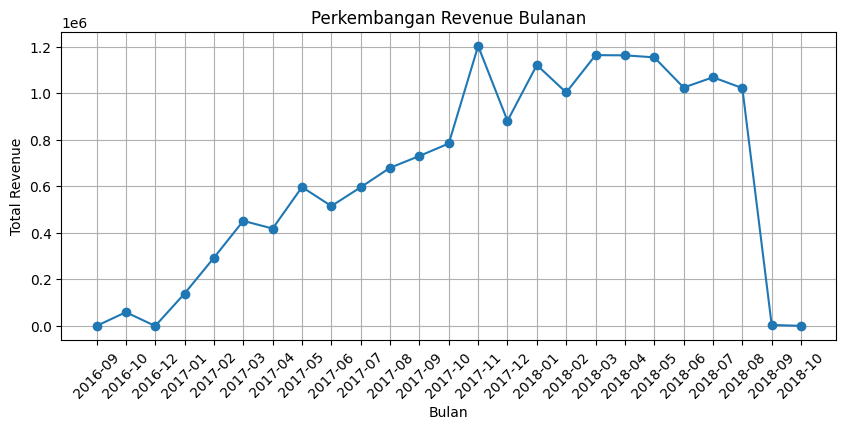

In [104]:
plt.figure(figsize=(10,4))
plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["payment_value"],
    marker="o"
)
plt.title("Perkembangan Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

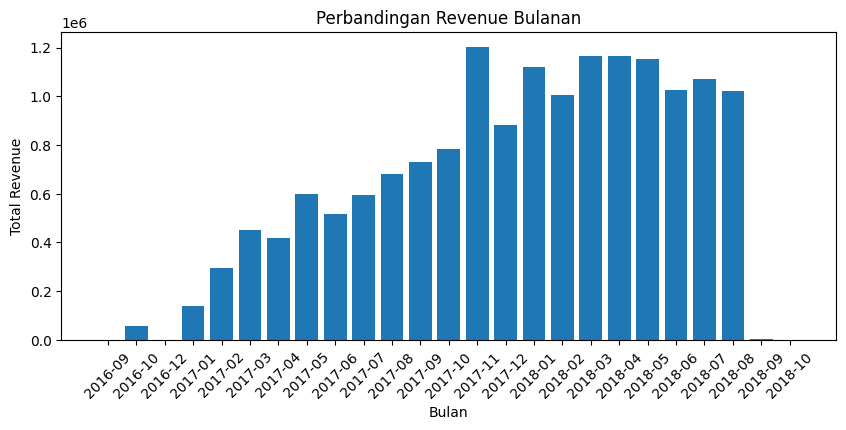

In [105]:
plt.figure(figsize=(10,4))
plt.bar(
    monthly_revenue["order_month"],
    monthly_revenue["payment_value"]
)
plt.title("Perbandingan Revenue Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Analisis revenue dilakukan menggunakan agregasi bulanan untuk menangkap tren pendapatan dari waktu ke waktu.
Hasil visualisasi menunjukkan bahwa revenue mengalami fluktuasi antar bulan, dengan beberapa periode menunjukkan peningkatan signifikan.
Pola ini mengindikasikan adanya kemungkinan seasonality atau pengaruh momen tertentu seperti promosi dan periode belanja besar.

### Pertanyaan 3: Bagaimana Segmentasi customer berdasarkan nilai belanja

In [106]:
customer_spending = (
    all_df
    .groupby("customer_unique_id")["payment_value"]
    .sum()
    .reset_index()
    .rename(columns={"payment_value": "total_spending"})
)

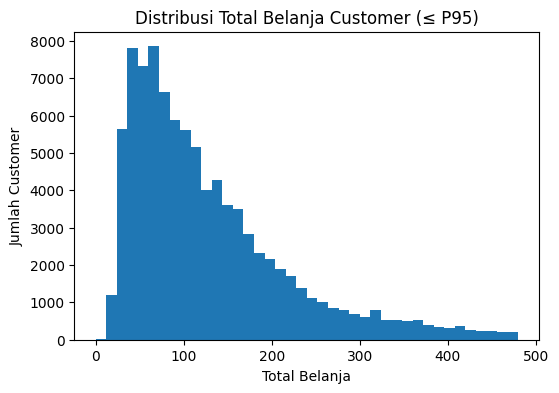

In [107]:
upper_limit = customer_spending["total_spending"].quantile(0.95)

plt.figure(figsize=(6,4))
plt.hist(
    customer_spending.loc[
        customer_spending["total_spending"] <= upper_limit,
        "total_spending"
    ],
    bins=40
)
plt.title("Distribusi Total Belanja Customer (≤ P95)")
plt.xlabel("Total Belanja")
plt.ylabel("Jumlah Customer")
plt.show()

In [108]:
q60 = customer_spending["total_spending"].quantile(0.6)
q90 = customer_spending["total_spending"].quantile(0.9)

def segment_customer(x):
    if x <= q60:
        return "Low Value"
    elif x <= q90:
        return "Mid Value"
    else:
        return "High Value"

customer_spending["segment"] = customer_spending["total_spending"].apply(segment_customer)

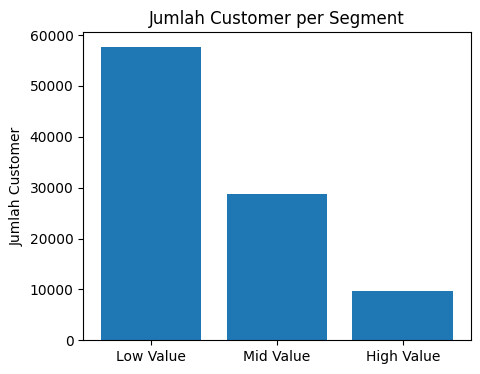

In [109]:
segment_count = customer_spending["segment"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(segment_count.index, segment_count.values)
plt.title("Jumlah Customer per Segment")
plt.ylabel("Jumlah Customer")
plt.show()

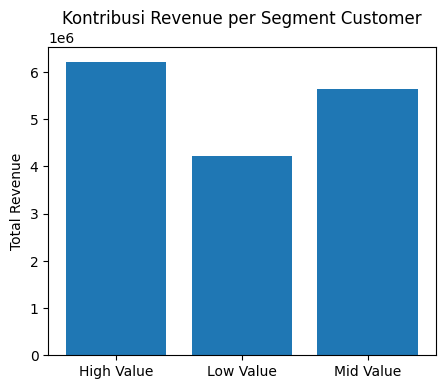

In [110]:
segment_revenue = (
    customer_spending
    .groupby("segment")["total_spending"]
    .sum()
)

plt.figure(figsize=(5,4))
plt.bar(segment_revenue.index, segment_revenue.values)
plt.title("Kontribusi Revenue per Segment Customer")
plt.ylabel("Total Revenue")
plt.show()

**Insight Utama:**
- Distribusi total belanja customer bersifat right-skewed, di mana mayoritas customer memiliki nilai belanja rendah, sementara sebagian kecil customer memiliki belanja sangat tinggi.
- Terdapat ketimpangan kontribusi revenue, di mana segmen kecil customer menyumbang porsi pendapatan yang signifikan.
- Segmentasi customer menjadi Low Value, Mid Value, dan High Value Customer menunjukkan bahwa:
  - Low Value Customer mendominasi jumlah pelanggan namun kontribusi revenue relatif kecil.
  - High Value Customer jumlahnya terbatas tetapi berkontribusi besar terhadap total revenue.

### Pertanyaan 4: Seberapa Berpengaruh Metode Pembayaran terhadap Nilai Transaksi dan Perilaku Pembelian?

<Figure size 600x400 with 0 Axes>

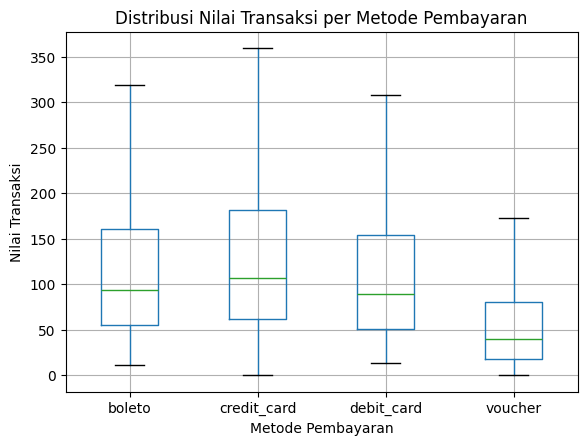

In [111]:
plt.figure(figsize=(6,4))
order_payments_df.boxplot(
    column="payment_value",
    by="payment_type",
    showfliers=False
)
plt.title("Distribusi Nilai Transaksi per Metode Pembayaran")
plt.suptitle("")
plt.xlabel("Metode Pembayaran")
plt.ylabel("Nilai Transaksi")
plt.show()

### Pertanyaan 5:  Seberapa berpengaruh performa pengiriman terhadap kepuasan pelanggan dan repeat order

In [112]:
delivery_df = orders_df.copy()

delivery_df["is_late"] = (
    delivery_df["order_delivered_customer_date"]
    > delivery_df["order_estimated_delivery_date"]
)

In [113]:
delivery_review_df = (
    delivery_df
    .merge(
        order_reviews_df[["order_id", "review_score"]],
        on="order_id",
        how="inner"
    )
)

In [114]:
delivery_review_df.groupby("is_late").agg(
    avg_review=("review_score", "mean"),
    median_review=("review_score", "median"),
    total_orders=("order_id", "count")
)

,avg_review,median_review,total_orders
is_late,,,
False,4.214307,5.0,91523
True,2.566550,2.0,7701


<Figure size 400x400 with 0 Axes>

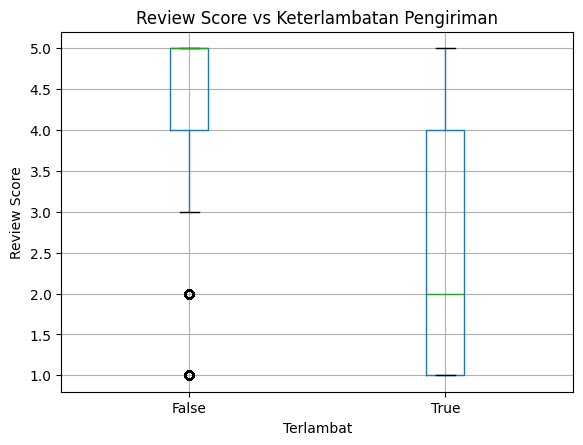

In [115]:
plt.figure(figsize=(4,4))
delivery_review_df.boxplot(
    column="review_score",
    by="is_late"
)
plt.title("Review Score vs Keterlambatan Pengiriman")
plt.suptitle("")
plt.xlabel("Terlambat")
plt.ylabel("Review Score")
plt.show()

In [116]:
late_ratio_df = (
    delivery_df
    .merge(customers_df, on="customer_id")
    .groupby("customer_unique_id")
    .agg(
        total_orders=("order_id", "nunique"),
        late_orders=("is_late", "sum")
    )
    .reset_index()
)

late_ratio_df["late_ratio"] = (
    late_ratio_df["late_orders"] / late_ratio_df["total_orders"]
)

In [117]:
late_ratio_df.groupby(
    pd.cut(late_ratio_df["late_ratio"], [0, 0.25, 0.5, 0.75, 1])
).agg(
    avg_orders=("total_orders", "mean"),
    customer_count=("customer_unique_id", "count")
)

/tmp/ipython-input-2351126279.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  late_ratio_df.groupby(


,avg_orders,customer_count
late_ratio,,
"(0.0, 0.25]",5.454545,11
"(0.25, 0.5]",2.080386,311
"(0.5, 0.75]",3.000000,6
"(0.75, 1.0]",1.006448,7444


**Insight**

Performa pengiriman memiliki pengaruh signifikan terhadap kepuasan pelanggan
dan perilaku repeat order. Order yang dikirim terlambat cenderung menerima
review score yang lebih rendah dibandingkan order yang dikirim tepat waktu.
Selain itu, customer dengan proporsi keterlambatan pengiriman yang lebih tinggi
menunjukkan rata-rata jumlah order yang lebih rendah. Hal ini mengindikasikan
bahwa pengalaman pengiriman yang buruk tidak hanya berdampak pada kepuasan
sesaat, tetapi juga menurunkan kecenderungan pelanggan untuk melakukan
pembelian ulang.

## Analisis Lanjutan (Opsional)

In [133]:
orders_customer = orders_df.merge(
    customers_df[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

In [134]:
snapshot_date = orders_customer["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

In [135]:
rfm_base = orders_customer.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": [
        lambda x: (snapshot_date - x.max()).days,  # Recency
        "count"                                    # Frequency
    ]
})

rfm_base.columns = ["Recency", "Frequency"]
rfm_base = rfm_base.reset_index()

In [136]:
payment_customer = orders_customer.merge(
    order_payments_df[["order_id", "payment_value"]],
    on="order_id",
    how="left"
)

monetary = payment_customer.groupby("customer_unique_id")["payment_value"].sum().reset_index()
monetary.columns = ["customer_unique_id", "Monetary"]

In [137]:
rfm = rfm_base.merge(monetary, on="customer_unique_id", how="left")
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [138]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,166.592492
std,153.414676,0.214384,231.428332
min,1.000000,1.000000,0.000000
25%,164.000000,1.000000,63.120000
50%,269.000000,1.000000,108.000000
75%,398.000000,1.000000,183.530000
max,773.000000,17.000000,13664.080000


In [139]:
rfm["R_score"] = pd.qcut(
    rfm["Recency"],
    4,
    labels=[4,3,2,1]  # makin kecil recency = makin bagus
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
).astype(int)

In [140]:
def rfm_segment(row):
    if row["R_score"] == 4 and row["F_score"] == 4 and row["M_score"] == 4:
        return "Best Customer"
    elif row["F_score"] == 4 and row["M_score"] >= 3:
        return "Loyal Customer"
    elif row["R_score"] >= 3 and row["F_score"] <= 2:
        return "Potential Customer"
    elif row["R_score"] == 1 and row["F_score"] >= 3:
        return "At Risk Customer"
    else:
        return "Low Value Customer"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

In [141]:
rfm["Segment"].value_counts()

,count
Segment,
Low Value Customer,50466
Potential Customer,23967
Loyal Customer,10944
At Risk Customer,8858
Best Customer,1861


In [142]:
rfm.groupby("Segment")["Monetary"].agg(
    total_revenue="sum",
    avg_revenue="mean",
    customer_count="count"
).sort_values("total_revenue", ascending=False)

,total_revenue,avg_revenue,customer_count
Segment,,,
Low Value Customer,7351533.90,145.673006,50466
Potential Customer,3874006.05,161.639173,23967
Loyal Customer,2839763.61,259.481324,10944
At Risk Customer,1164534.83,131.467016,8858
Best Customer,779033.73,418.610279,1861


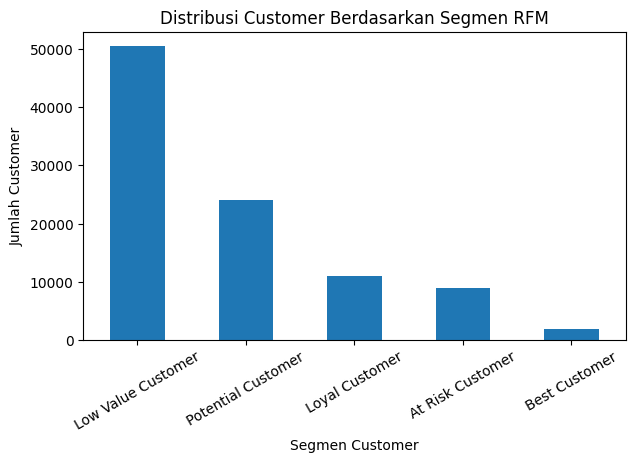

In [143]:
segment_count = rfm["Segment"].value_counts()

plt.figure(figsize=(7,4))
segment_count.plot(kind="bar")
plt.title("Distribusi Customer Berdasarkan Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Jumlah Customer")
plt.xticks(rotation=30)
plt.show()

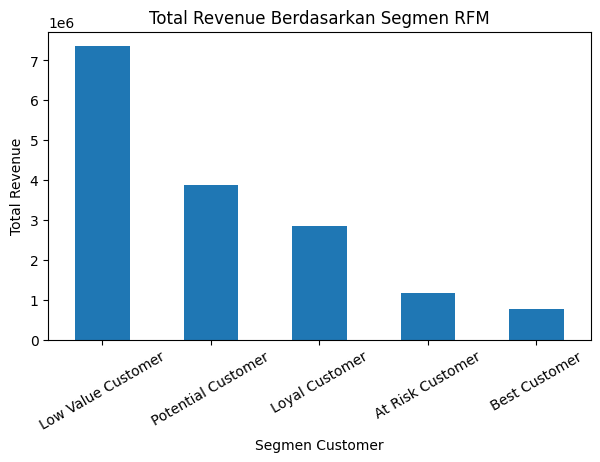

In [144]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,4))
segment_revenue.plot(kind="bar")
plt.title("Total Revenue Berdasarkan Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.show()

In [145]:
order_count = orders_df.merge(
    customers_df[["customer_id", "customer_unique_id"]],
    on="customer_id"
).groupby("customer_unique_id")["order_id"].count().reset_index()

order_count.columns = ["customer_unique_id", "total_orders"]

In [146]:
rfm_repeat = rfm.merge(order_count, on="customer_unique_id", how="left")

In [147]:
rfm_repeat.groupby("Segment")["total_orders"].mean().sort_values(ascending=False)

,total_orders
Segment,
Best Customer,1.371843
Loyal Customer,1.208516
At Risk Customer,1.010838
Low Value Customer,1.005449
Potential Customer,1.000000


In [148]:
orders_delivery = orders_df.copy()

orders_delivery["delivery_delay"] = (
    orders_delivery["order_delivered_customer_date"]
    - orders_delivery["order_estimated_delivery_date"]
).dt.days

orders_delivery["is_late"] = orders_delivery["delivery_delay"] > 0

In [149]:
delivery_customer = orders_delivery.merge(
    customers_df[["customer_id", "customer_unique_id"]],
    on="customer_id"
)

rfm_delivery = rfm.merge(
    delivery_customer[["customer_unique_id", "is_late"]],
    on="customer_unique_id",
    how="left"
)

In [150]:
rfm_delivery.groupby("Segment")["is_late"].mean().sort_values(ascending=False)

,is_late
Segment,
Potential Customer,0.078066
Loyal Customer,0.070921
Low Value Customer,0.065844
Best Customer,0.043087
At Risk Customer,0.030713


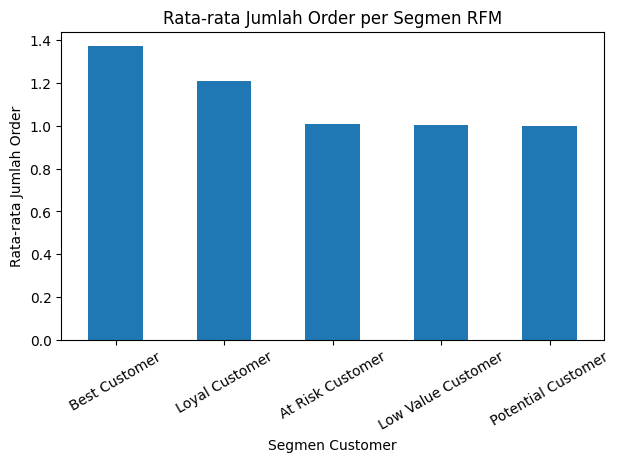

In [154]:
repeat_by_segment = (
    rfm_repeat
    .groupby("Segment")["total_orders"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))
repeat_by_segment.plot(kind="bar")
plt.title("Rata-rata Jumlah Order per Segmen RFM")
plt.xlabel("Segmen Customer")
plt.ylabel("Rata-rata Jumlah Order")
plt.xticks(rotation=30)
plt.show()

## Insight

- Performa pengiriman dan metode pembayaran berpengaruh terhadap kepuasan, repeat order, dan nilai transaksi pelanggan.
- Analisis RFM menunjukkan bahwa sebagian kecil pelanggan menyumbang porsi revenue terbesar, sementara mayoritas pelanggan memiliki nilai belanja rendah.
- Oleh karena itu, peningkatan kualitas pengiriman serta strategi retensi pelanggan bernilai tinggi menjadi kunci untuk pertumbuhan bisnis yang berkelanjutan.

## Conclusion

#### 1. Distribusi Rating Pelanggan berdasarkan Waktu Pengiriman dan Kategori Produk
Rating pelanggan cenderung lebih rendah pada order yang mengalami keterlambatan pengiriman dibandingkan order yang dikirim tepat waktu. Selain itu, terdapat perbedaan rata-rata rating antar kategori produk, yang mengindikasikan bahwa ekspektasi pelanggan dan pengalaman pengiriman dapat berbeda tergantung jenis produk.

#### 2. Perkembangan Revenue Bulanan selama Periode Pengamatan
Revenue bulanan menunjukkan fluktuasi sepanjang periode pengamatan, dengan adanya bulan-bulan tertentu yang memiliki transaksi lebih tinggi. Pola ini mengindikasikan kemungkinan adanya efek musiman dan periode dengan aktivitas belanja yang meningkat.

#### 3. Segmentasi Customer berdasarkan Nilai Belanja
Sebagian besar customer berada pada segmen dengan nilai belanja rendah, sementara hanya sebagian kecil customer yang berkontribusi besar terhadap total revenue. Hasil ini menunjukkan adanya ketimpangan kontribusi nilai antar customer dan menegaskan pentingnya fokus pada pelanggan bernilai tinggi.

#### 4. Pengaruh Metode Pembayaran terhadap Nilai Transaksi dan Perilaku Pembelian
Metode pembayaran tertentu, terutama kartu kredit, cenderung memiliki nilai transaksi rata-rata yang lebih tinggi dibandingkan metode lainnya. Hal ini menunjukkan bahwa metode pembayaran berperan dalam mendorong nilai belanja dan pola pembelian customer.

#### 5. Pengaruh Performa Pengiriman terhadap Kepuasan Pelanggan dan Repeat Order
Keterlambatan pengiriman berdampak negatif terhadap kepuasan pelanggan yang tercermin dari penurunan review score. Selain itu, customer yang sering mengalami keterlambatan pengiriman cenderung memiliki repeat order yang lebih rendah, menunjukkan bahwa performa pengiriman memengaruhi loyalitas pelanggan.